# Project Dataset: Employee Salary at BananaByte




Description of the dataset and questions: <break>

This dataset contains employee information covering demographics and their correlation to employee salary.


Questions I would like to answer through the use of data analytics are: <break>

1) Is there a correlation education and employee salary?

2) Are there noticable gender pay gaps when comparing salaries and bonuses.

3) How does employee location impact salary across jobs with similar roles.




#### Variable Descriptions
---
**Employee_ID:** Employee ID  <break>

**Gender:** Gender <break>

**Years_Exp:** Years of experience <break>

**Years_Seniority:** Years of Seniority in Company (Years in a senior Job Level) <break>

**Edu_Level:** Educational Level of Attainment (Degree) <break>

**Perf:** Performance Rating <break>

**Job_Role:** Job Role <break>

**Job_Family:** Job Family (Department) <break>

**Job_Level:** Job Level <break>

**Job_Location:** Job Location <break>


##1. Prepare Data


###a) Load & Examine Data
---
In this step we will mount the data, import libraries, and perform a preliminary examination of the dataset.

In [1]:
# Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeRegressor
import statsmodels.api as sm
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from collections import Counter

In [3]:
# Read data
salary = pd.read_csv('/content/drive/MyDrive/BAIS320_data/BananaByte_Salary.csv')
salary

,Employee_ID,Gender,Years_Exp,Years_Seniority,Edu_Level,Perf,Job_Role,Job_Family,Job_Level,Job_Location,Market_Median,Salary,Bonus_FY,Total_Compensation
0,269715XN,Male,17.9,0.8,masters,NaN,Chief Executive Officer,Leadership,Executive-Level,"San Francisco, CA",4185017.85,2449867.7,1225000.2,3674866.5
1,11324975,Female,25.0,22.9,doctorate,NaN,Chief Operating Officer,Leadership,Executive-Level,"San Francisco, CA",1082084.12,742964.8,372500.9,1115464.0
2,35645BZB,Female,20.4,11.8,doctorate,NaN,Chief Financial Officer,Leadership,Executive-Level,"San Francisco, CA",1182923.43,514671.4,257500.9,772171.1
3,783731F7,Male,23.3,4.1,doctorate,NaN,Chief Information Officer,Leadership,Executive-Level,"San Francisco, CA",1006076.76,509194.7,255000.9,764194.6
4,34718QIA,Female,19.0,1.7,doctorate,NaN,Vice Presidents,Leadership,Executive-Level,"San Francisco, CA",639996.89,398064.6,200000.3,598063.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11509,61526BHG,Female,1.3,0.4,bachelors,5.5,Customer Service Representative,Customer Service,Entry-Level,"Seattle, WA",59161.68,30462.0,2500.1,32961.4
11510,86936YDN,Male,1.1,0.5,bachelors,4.5,Customer Service Representative,Customer Service,Entry-Level,"Boston, MA",63043.68,30182.4,2500.1,32682.0
11511,32487P5K,Male,3.4,0.3,high school,3.4,Customer Service Representative,Customer Service,Entry-Level,"Boston, MA",63043.68,30164.9,2500.0,32663.8
11512,201982LK,Male,1.6,0.1,high school,2.3,Customer Service Representative,Customer Service,Entry-Level,"San Francisco, CA",76203.66,29785.4,2500.5,32285.6


In [4]:
# Examine the number of rows and cols
salary.shape

(11514, 14)

In [5]:
# Display The First 10 Rows
salary.head(n=10)

,Employee_ID,Gender,Years_Exp,Years_Seniority,Edu_Level,Perf,Job_Role,Job_Family,Job_Level,Job_Location,Market_Median,Salary,Bonus_FY,Total_Compensation
0,269715XN,Male,17.9,0.8,masters,NaN,Chief Executive Officer,Leadership,Executive-Level,"San Francisco, CA",4185017.85,2449867.7,1225000.2,3674866.5
1,11324975,Female,25.0,22.9,doctorate,NaN,Chief Operating Officer,Leadership,Executive-Level,"San Francisco, CA",1082084.12,742964.8,372500.9,1115464.0
2,35645BZB,Female,20.4,11.8,doctorate,NaN,Chief Financial Officer,Leadership,Executive-Level,"San Francisco, CA",1182923.43,514671.4,257500.9,772171.1
3,783731F7,Male,23.3,4.1,doctorate,NaN,Chief Information Officer,Leadership,Executive-Level,"San Francisco, CA",1006076.76,509194.7,255000.9,764194.6
4,34718QIA,Female,19.0,1.7,doctorate,NaN,Vice Presidents,Leadership,Executive-Level,"San Francisco, CA",639996.89,398064.6,200000.3,598063.0
5,8939353Y,Male,22.1,3.8,doctorate,NaN,Vice Presidents,Leadership,Executive-Level,"San Francisco, CA",639996.89,390258.6,195000.2,585258.1
6,37585FOD,Female,25.7,1.3,masters,NaN,Vice Presidents,Leadership,Executive-Level,"San Francisco, CA",639996.89,390258.6,195000.5,585258.7
7,385703IC,Male,21.6,7.5,doctorate,NaN,Vice Presidents,Leadership,Executive-Level,"San Francisco, CA",639996.89,378551.3,190000.0,568550.7
8,48860BG9,Female,21.6,18.6,doctorate,NaN,Vice Presidents,Leadership,Executive-Level,"San Francisco, CA",639996.89,359038.9,180000.8,539037.6
9,216976R2,Male,15.9,5.3,doctorate,NaN,Vice Presidents,Leadership,Executive-Level,"San Francisco, CA",639996.89,355135.0,177500.1,532635.3


In [6]:
# Display The Last 10 Rows
salary.tail(n=10)

,Employee_ID,Gender,Years_Exp,Years_Seniority,Edu_Level,Perf,Job_Role,Job_Family,Job_Level,Job_Location,Market_Median,Salary,Bonus_FY,Total_Compensation
11504,21187LN6,Female,2.1,0.0,high school,3.5,Customer Service Representative,Customer Service,Entry-Level,"Los Angeles, CA",67275.06,31386.7,2500.0,33886.2
11505,50519ZBB,Male,1.7,0.9,bachelors,3.5,Customer Service Representative,Customer Service,Entry-Level,"San Francisco, CA",76203.66,31374.8,2500.5,33873.8
11506,80872TVF,Female,2.3,1.6,bachelors,3.2,Customer Service Representative,Customer Service,Entry-Level,"San Francisco, CA",76203.66,31299.3,2500.7,33799.1
11507,70061HBP,Male,1.6,0.0,bachelors,2.4,Customer Service Representative,Customer Service,Entry-Level,"Seattle, WA",59161.68,31299.8,2500.2,33799.9
11508,9798801Q,Female,2.1,1.1,high school,2.4,Customer Service Representative,Customer Service,Entry-Level,"Seattle, WA",59161.68,30968.4,2500.0,33467.7
11509,61526BHG,Female,1.3,0.4,bachelors,5.5,Customer Service Representative,Customer Service,Entry-Level,"Seattle, WA",59161.68,30462.0,2500.1,32961.4
11510,86936YDN,Male,1.1,0.5,bachelors,4.5,Customer Service Representative,Customer Service,Entry-Level,"Boston, MA",63043.68,30182.4,2500.1,32682.0
11511,32487P5K,Male,3.4,0.3,high school,3.4,Customer Service Representative,Customer Service,Entry-Level,"Boston, MA",63043.68,30164.9,2500.0,32663.8
11512,201982LK,Male,1.6,0.1,high school,2.3,Customer Service Representative,Customer Service,Entry-Level,"San Francisco, CA",76203.66,29785.4,2500.5,32285.6
11513,54802EZ8,Male,2.1,1.0,bachelors,3.3,Customer Service Representative,Customer Service,Entry-Level,"Chicago, IL",41498.58,29681.9,2500.8,32180.9


In [7]:
# Examine the Number of Rows
len(salary)

11514

In [8]:
# Examine the Index
salary.index

RangeIndex(start=0, stop=11514, step=1)

In [9]:
# Examine the Columns
salary.columns

Index(['Employee_ID', 'Gender', 'Years_Exp', 'Years_Seniority', 'Edu_Level',
       'Perf', 'Job_Role', 'Job_Family', 'Job_Level', 'Job_Location',
       'Market_Median', 'Salary', 'Bonus_FY', 'Total_Compensation'],
      dtype='object')

###b) Clean Data
---
In this step we will address any missing(null) or duplicate values.

In [10]:
# Examine Missing Values
salary.isnull().sum()

,0
Employee_ID,0
Gender,0
Years_Exp,0
Years_Seniority,0
Edu_Level,0
Perf,19
Job_Role,0
Job_Family,0
Job_Level,0
Job_Location,0


In [11]:
#Examine the Total Number of Missing Values
salary.isnull().sum().sum()

np.int64(19)

Since we have 19 missing values in the performance rating category, we will need to drop all null values.

In [12]:
# Drop Missing Values
salary = salary.dropna(axis = 0, how = 'any')
salary

,Employee_ID,Gender,Years_Exp,Years_Seniority,Edu_Level,Perf,Job_Role,Job_Family,Job_Level,Job_Location,Market_Median,Salary,Bonus_FY,Total_Compensation
19,1770417D,Female,13.6,8.8,doctorate,4.0,Director,Leadership,Management-Level,"San Francisco, CA",466448.06,295809.4,132500.3,428308.4
20,787555DV,Male,13.4,1.6,masters,5.4,Director,Leadership,Management-Level,"Los Angeles, CA",411795.46,277759.5,140000.4,417759.6
21,89429HKM,Female,13.2,2.1,masters,3.4,Director,Leadership,Management-Level,"New York, NY",444824.64,295410.0,117500.6,412909.5
22,16212BAV,Female,10.2,3.0,doctorate,3.4,Director,Leadership,Management-Level,"San Francisco, CA",466448.06,292965.1,117500.9,410464.6
23,55491ZA0,Female,14.5,4.8,masters,2.8,Director,Leadership,Management-Level,"San Francisco, CA",466448.06,295809.5,102500.8,398308.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11509,61526BHG,Female,1.3,0.4,bachelors,5.5,Customer Service Representative,Customer Service,Entry-Level,"Seattle, WA",59161.68,30462.0,2500.1,32961.4
11510,86936YDN,Male,1.1,0.5,bachelors,4.5,Customer Service Representative,Customer Service,Entry-Level,"Boston, MA",63043.68,30182.4,2500.1,32682.0
11511,32487P5K,Male,3.4,0.3,high school,3.4,Customer Service Representative,Customer Service,Entry-Level,"Boston, MA",63043.68,30164.9,2500.0,32663.8
11512,201982LK,Male,1.6,0.1,high school,2.3,Customer Service Representative,Customer Service,Entry-Level,"San Francisco, CA",76203.66,29785.4,2500.5,32285.6


In [13]:
# Re-examine the Total Number Of Missing Values
salary.isnull().sum().sum()

np.int64(0)

In [14]:
# Examine the Total Number of Duplicate Values
salary.duplicated().sum()

np.int64(0)

There are no more duplicate values, I will additionally drop EmployeeID since it is not needed.

In [15]:
# Drop Employee_ID
salary = salary.drop('Employee_ID', axis=1)

In [16]:
# Re-index the Dataset
salary = salary.reset_index(drop = True)
salary

,Gender,Years_Exp,Years_Seniority,Edu_Level,Perf,Job_Role,Job_Family,Job_Level,Job_Location,Market_Median,Salary,Bonus_FY,Total_Compensation
0,Female,13.6,8.8,doctorate,4.0,Director,Leadership,Management-Level,"San Francisco, CA",466448.06,295809.4,132500.3,428308.4
1,Male,13.4,1.6,masters,5.4,Director,Leadership,Management-Level,"Los Angeles, CA",411795.46,277759.5,140000.4,417759.6
2,Female,13.2,2.1,masters,3.4,Director,Leadership,Management-Level,"New York, NY",444824.64,295410.0,117500.6,412909.5
3,Female,10.2,3.0,doctorate,3.4,Director,Leadership,Management-Level,"San Francisco, CA",466448.06,292965.1,117500.9,410464.6
4,Female,14.5,4.8,masters,2.8,Director,Leadership,Management-Level,"San Francisco, CA",466448.06,295809.5,102500.8,398308.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11490,Female,1.3,0.4,bachelors,5.5,Customer Service Representative,Customer Service,Entry-Level,"Seattle, WA",59161.68,30462.0,2500.1,32961.4
11491,Male,1.1,0.5,bachelors,4.5,Customer Service Representative,Customer Service,Entry-Level,"Boston, MA",63043.68,30182.4,2500.1,32682.0
11492,Male,3.4,0.3,high school,3.4,Customer Service Representative,Customer Service,Entry-Level,"Boston, MA",63043.68,30164.9,2500.0,32663.8
11493,Male,1.6,0.1,high school,2.3,Customer Service Representative,Customer Service,Entry-Level,"San Francisco, CA",76203.66,29785.4,2500.5,32285.6


### c) Data Transformation
---
In this step we will address the data types and merge any datasets where needed.

In [17]:
# Examine the Variable Data Types
salary.dtypes

,0
Gender,object
Years_Exp,float64
Years_Seniority,float64
Edu_Level,object
Perf,float64
Job_Role,object
Job_Family,object
Job_Level,object
Job_Location,object
Market_Median,float64


In [18]:
# Change Categorical Variables to 'Category'
salary['Gender'] = salary['Gender'].astype('category')
salary['Edu_Level'] = salary['Edu_Level'].astype('category')
salary['Job_Role'] = salary['Job_Role'].astype('category')
salary['Job_Family'] = salary['Job_Family'].astype('category')
salary['Job_Level'] = salary['Job_Level'].astype('category')
salary['Job_Location'] = salary['Job_Location'].astype('category')


In [19]:
# Re-examine Variable Types
salary.dtypes

,0
Gender,category
Years_Exp,float64
Years_Seniority,float64
Edu_Level,category
Perf,float64
Job_Role,category
Job_Family,category
Job_Level,category
Job_Location,category
Market_Median,float64


##2. Is there a correlation between employee education and salary at BananaByte?

###a) Identify parameters and examine data regarding education level and salary

---
LAB: 1 & 4


In [20]:
# Obtain the Years_Exp and Salary for every employee
salary[['Edu_Level','Salary']]

,Edu_Level,Salary
0,doctorate,295809.4
1,masters,277759.5
2,masters,295410.0
3,doctorate,292965.1
4,masters,295809.5
...,...,...
11490,bachelors,30462.0
11491,bachelors,30182.4
11492,high school,30164.9
11493,high school,29785.4


In [21]:
# Find the mean and median of the exployee salaries
print("Mean:",salary['Salary'].mean(), "Median:",salary['Salary'].median())

Mean: 106697.59689430187 Median: 106935.6


### b) Create Data Visualizations showing the effects of employee education on salary

---
LAB: 1 & 4

Text(0.5, 1.0, 'Countplot showing number of employees with varying levels of education')

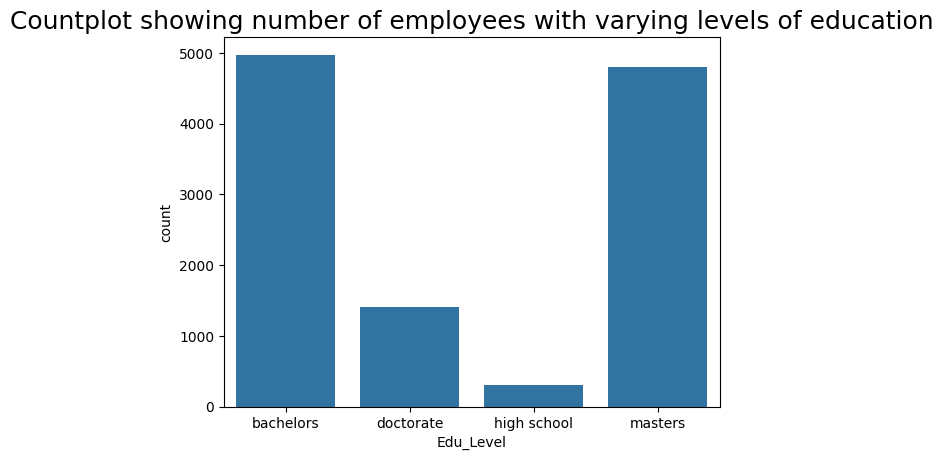

In [22]:
snsplot = sns.countplot(x = 'Edu_Level', data = salary)
snsplot.set_title("Countplot showing number of employees with varying levels of education", fontsize=18)

Text(0.5, 1.0, 'Boxplot of education level and salaries')

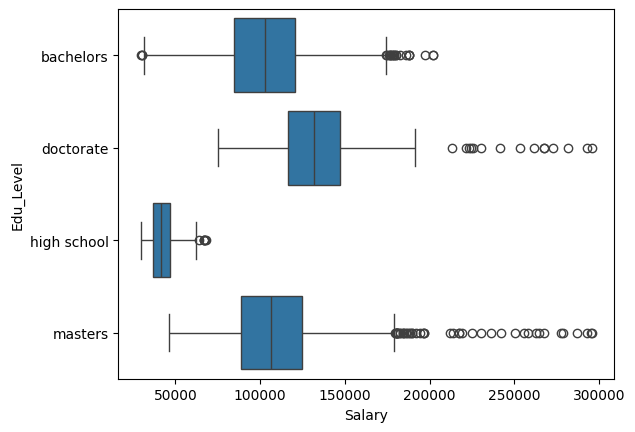

In [23]:
# Create a Boxplots to show the Education Level and Salary
sns.boxplot(x = "Salary", y = 'Edu_Level', data = salary)
snsplot.set_title("Boxplot of education level and salaries")

Text(0.5, 1.0, 'Histogram of salary and education level at BananaByte')

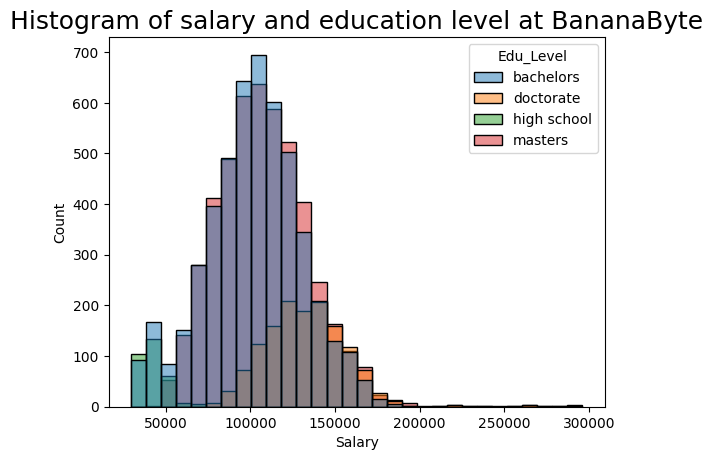

In [24]:
# Histogram of a numeric variable: 'Salary', set hue = 'Edu_Level', add bins
snsplot = sns.histplot(x = 'Salary', data = salary, hue = 'Edu_Level', bins = 30)
snsplot.set_title("Histogram of salary and education level at BananaByte", fontsize=18)

Is there a correlation between employee education and salary at BananaByte?
---

Based on our data we know that the vast majority of BananaByte's staff is made up of bachelors and masters graduates. As indicated by the the boxplot the median and mean salary amounts directly support the idea that education level is directly correlated with salary at BananaByte. You can see that there are significant overlap between the salaries and education levels but there is an overwheling trend of Higher Education Level = Higher Salary.




##3. Are there noticeable gender pay gaps when comparing salaries and bonuses.

####a) Create Data Visualizations to show the differences between bonus/salary and the two genders across similar roles.
----
LAB: 4

Text(0.5, 1.0, 'Boxplot of Gender and salaries')

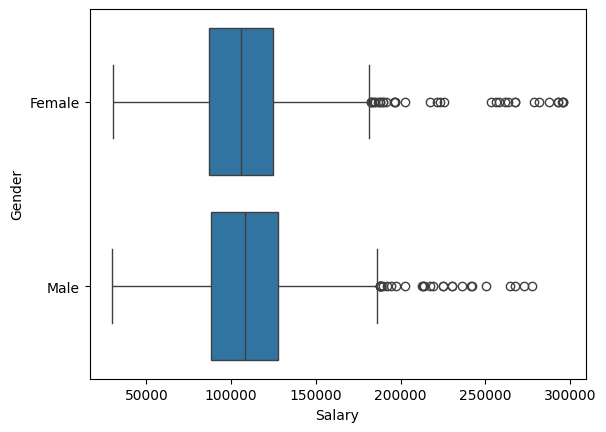

In [25]:
# Create a Boxplots to show the Gender and Salary
sns.boxplot(x = "Salary", y = 'Gender', data = salary)
snsplot.set_title("Boxplot of Gender and salaries")

Text(0.5, 1.0, 'Boxplot of Gender and Bonus')

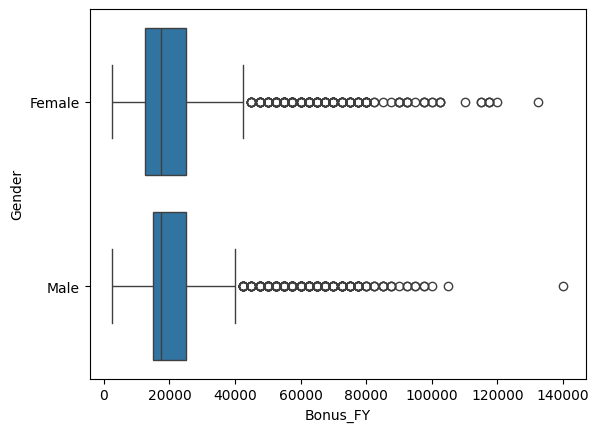

In [26]:
# Create a Boxplots to show the Gender and Bonus
sns.boxplot(x = "Bonus_FY", y = 'Gender', data = salary)
snsplot.set_title("Boxplot of Gender and Bonus")

####b) Analyze the total compensation of the two genders
----
LAB: 4

/tmp/ipython-input-1569874236.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  snsplot.set_xticklabels(snsplot.get_xticklabels(), rotation=40, ha="right")


Text(0.5, 1.0, 'barplot of Gender and total compensaiton across job families')

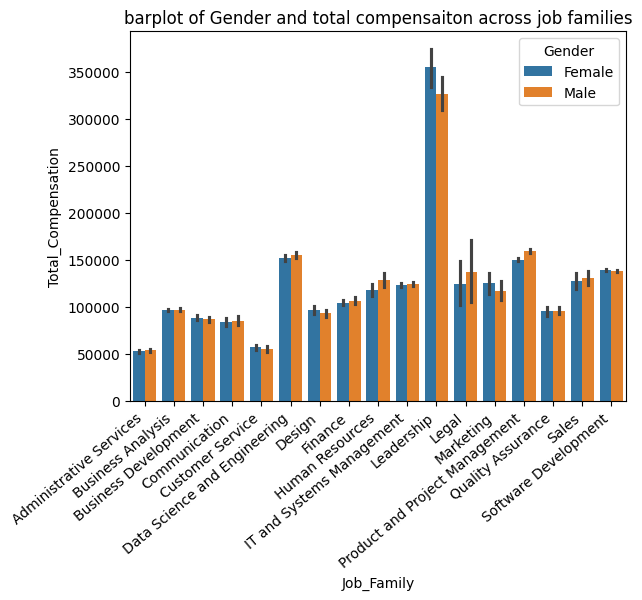

In [27]:
# Barplot comparing gender and total compesation across multiple job families
snsplot = sns.barplot(x='Job_Family', y = 'Total_Compensation', data=salary, hue='Gender')
snsplot.set_xticklabels(snsplot.get_xticklabels(), rotation=40, ha="right")
snsplot.set_title("barplot of Gender and total compensaiton across job families")

Text(0.5, 1.0, 'Boxplot of Gender and Total Compensation')

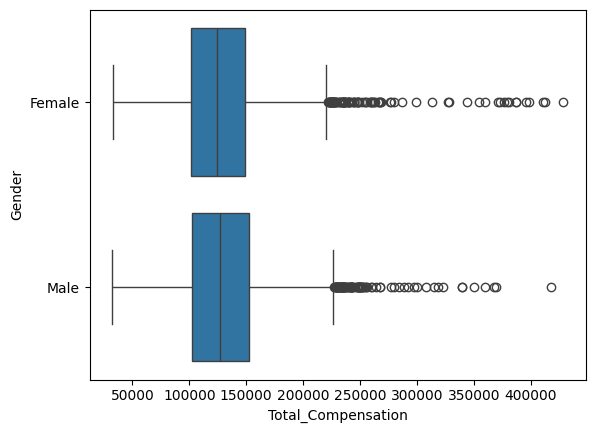

In [28]:
# Create a Boxplots to show the Gender and Total Compensation
sns.boxplot(x = "Total_Compensation", y = 'Gender', data = salary)
snsplot.set_title("Boxplot of Gender and Total Compensation")

Are there noticeable gender pay gaps when comparing salaries and bonuses.
----
Salary and bonuses are very similar in terms of range and median with the bonus for men being slightly lower. In the following diagrams comparing total compensation it seems to have similar results. You can notice in terms of total compensation, the women category has more outliers. Total compensation across differnt job families shows that there is not not much inequality in terms of compensation between the two gender categories and there are minor differences only in the job roles.

##4. How does employee location impact job salary across similar roles?

###a) Create a visualization comparing salary as a whole across different locations
---
LAB: 4

Text(0.5, 1.0, 'Total Salary By Location')

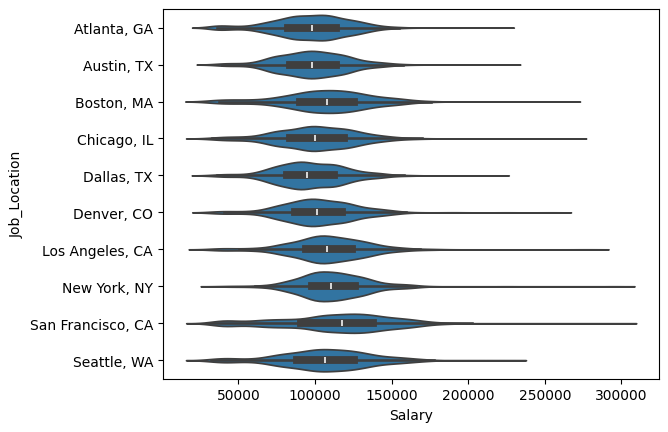

In [29]:
#Create a Violin plot comparing Job Location to Salary
sns.violinplot(x = 'Salary', y = 'Job_Location', data = salary)
snsplot.set_title("Total Salary By Location", fontsize = 18)

Higest median salaries:<br>
San Francisco, CA<br>
New York, NY


###b) Get dummy variables and perform normalization
---
LAB: 8 & 9


In [30]:
#Create dummy variables
salary_d= pd.get_dummies(salary, columns=['Job_Location', 'Job_Level', 'Gender', 'Edu_Level', 'Job_Role', 'Job_Family', 'Job_Location'], drop_first = True, dtype = int)
salary_d

,Years_Exp,Years_Seniority,Perf,Market_Median,Salary,Bonus_FY,Total_Compensation,"Job_Location_Austin, TX","Job_Location_Boston, MA","Job_Location_Chicago, IL",...,Job_Family_Software Development,"Job_Location_Austin, TX","Job_Location_Boston, MA","Job_Location_Chicago, IL","Job_Location_Dallas, TX","Job_Location_Denver, CO","Job_Location_Los Angeles, CA","Job_Location_New York, NY","Job_Location_San Francisco, CA","Job_Location_Seattle, WA"
0,13.6,8.8,4.0,466448.06,295809.4,132500.3,428308.4,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,13.4,1.6,5.4,411795.46,277759.5,140000.4,417759.6,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,13.2,2.1,3.4,444824.64,295410.0,117500.6,412909.5,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,10.2,3.0,3.4,466448.06,292965.1,117500.9,410464.6,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,14.5,4.8,2.8,466448.06,295809.5,102500.8,398308.3,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11490,1.3,0.4,5.5,59161.68,30462.0,2500.1,32961.4,0,0,0,...,0,0,0,0,0,0,0,0,0,1
11491,1.1,0.5,4.5,63043.68,30182.4,2500.1,32682.0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
11492,3.4,0.3,3.4,63043.68,30164.9,2500.0,32663.8,0,1,0,...,0,0,1,0,0,0,0,0,0,0
11493,1.6,0.1,2.3,76203.66,29785.4,2500.5,32285.6,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [31]:
salary_d.columns

Index(['Years_Exp', 'Years_Seniority', 'Perf', 'Market_Median', 'Salary',
       'Bonus_FY', 'Total_Compensation', 'Job_Location_Austin, TX',
       'Job_Location_Boston, MA', 'Job_Location_Chicago, IL',
       ...
       'Job_Family_Software Development', 'Job_Location_Austin, TX',
       'Job_Location_Boston, MA', 'Job_Location_Chicago, IL',
       'Job_Location_Dallas, TX', 'Job_Location_Denver, CO',
       'Job_Location_Los Angeles, CA', 'Job_Location_New York, NY',
       'Job_Location_San Francisco, CA', 'Job_Location_Seattle, WA'],
      dtype='object', length=102)

####NEW LOCATION COLUMNS:
---
'Job_Location_Austin, TX' <br>
'Job_Location_Boston, MA' <br>
'Job_Location_Chicago, IL' <br>
'Job_Location_Dallas, TX' <br>
'Job_Location_Denver, CO' <br>
'Job_Location_Los Angeles, CA' <br>
'Job_Location_New York, NY' <br>
'Job_Location_San Francisco, CA' <br>
'Job_Location_Seattle, WA' <br>





In [32]:
# Apply minmax normalization
min_max_scaler = preprocessing.MinMaxScaler()
salary_normalized = pd.DataFrame(min_max_scaler.fit_transform(salary_d))
salary_normalized.columns = salary_d.columns
salary_normalized


,Years_Exp,Years_Seniority,Perf,Market_Median,Salary,Bonus_FY,Total_Compensation,"Job_Location_Austin, TX","Job_Location_Boston, MA","Job_Location_Chicago, IL",...,Job_Family_Software Development,"Job_Location_Austin, TX","Job_Location_Boston, MA","Job_Location_Chicago, IL","Job_Location_Dallas, TX","Job_Location_Denver, CO","Job_Location_Los Angeles, CA","Job_Location_New York, NY","Job_Location_San Francisco, CA","Job_Location_Seattle, WA"
0,0.845638,0.590604,0.612245,1.000000,1.000000,9.454540e-01,1.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.832215,0.107383,0.897959,0.871987,0.932175,1.000000e+00,0.973370,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.818792,0.140940,0.489796,0.949351,0.998499,8.363656e-01,0.961126,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.617450,0.201342,0.489796,1.000000,0.989312,8.363677e-01,0.954954,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.906040,0.322148,0.367347,1.000000,1.000000,7.272764e-01,0.924267,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11490,0.020134,0.026846,0.918367,0.046010,0.002931,7.272706e-07,0.001970,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
11491,0.006711,0.033557,0.714286,0.055103,0.001881,7.272706e-07,0.001265,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11492,0.161074,0.020134,0.489796,0.055103,0.001815,0.000000e+00,0.001219,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11493,0.040268,0.006711,0.265306,0.085927,0.000389,3.636353e-06,0.000264,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


###c) Elbow Test
----
LAB:9

Text(0.5, 1.0, 'Elbow Test')

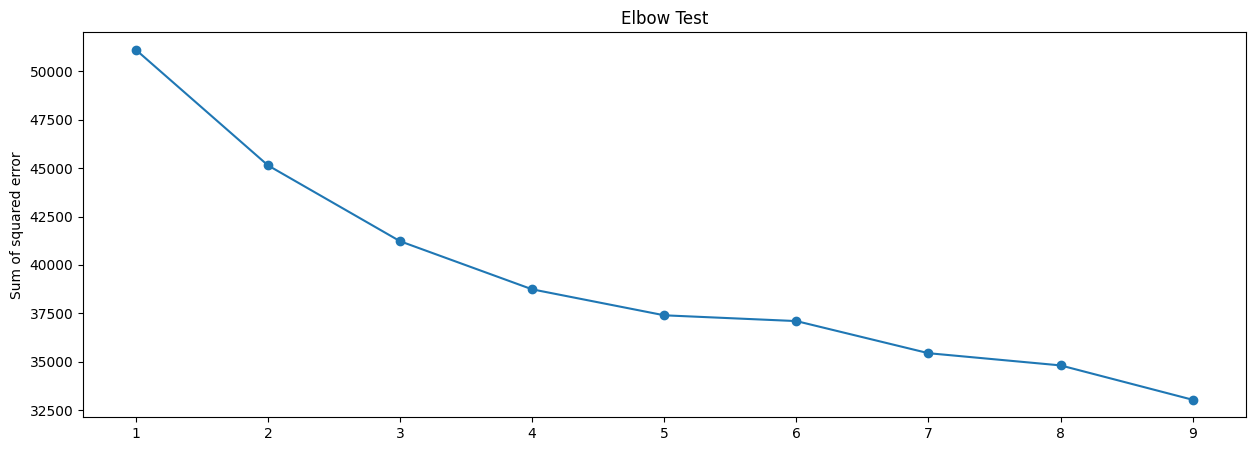

In [33]:
Sum_of_squared_error = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(salary_normalized)
    Sum_of_squared_error.append(kmeans.inertia_)

fig = plt.figure(figsize=(15, 5))
plt.scatter(range(1, 10), Sum_of_squared_error)
plt.plot(range(1, 10), Sum_of_squared_error)
plt.ylabel('Sum of squared error')
plt.title('Elbow Test')

###d) Clustering Model
----
LAB: 9

In [34]:
#Build a clustering model (n_clusers=4 from elbow test)
model1 = KMeans(n_clusters=4, random_state = 0)
model1.fit(salary_normalized)

KMeans(n_clusters=4, random_state=0)

In [35]:
# Generate the cluster labels
model1.labels_

array([2, 2, 2, ..., 0, 1, 0], dtype=int32)

In [36]:
# Show cluster size
Counter(model1.labels_)

Counter({np.int32(2): 2673,
         np.int32(0): 3329,
         np.int32(3): 1245,
         np.int32(1): 4248})

In [37]:
# Show cluster centroids
pd.DataFrame({'cluster 1':salary_d[model1.labels_==0].mean(axis=0), 'cluster 2':salary_d[model1.labels_==1].mean(axis=0), 'cluster 3':salary_d[model1.labels_==2].mean(axis=0), 'cluster 4':salary_d[model1.labels_==3].mean(axis=0)})

,cluster 1,cluster 2,cluster 3,cluster 4
Years_Exp,5.345689,5.229379,9.793715,9.994859
Years_Seniority,2.445689,2.357039,4.716124,4.741044
Perf,3.486272,3.453931,3.485559,3.456305
Market_Median,117861.967888,166606.163795,217227.754759,205017.391695
Salary,85886.319856,99715.928814,135179.291919,125016.710522
...,...,...,...,...
"Job_Location_Denver, CO",0.099429,0.040960,0.053872,0.054618
"Job_Location_Los Angeles, CA",0.091319,0.044727,0.050131,0.055422
"Job_Location_New York, NY",0.077200,0.037900,0.032548,0.036948
"Job_Location_San Francisco, CA",0.000000,0.556497,0.445941,0.424900


####c) Analyzing our data clusters
----
LAB: 9

Cluster 1: Lowest Paid Mid Level Employees  <br>
Mostly located in Dallas, Austin, Chicago, Denver, and Boston. These employees have around 5.35 years experience.
<br>

Cluster 2: Higher Paid Mid Level Employees <br>
Mostly located in Los Angeles, Denver and Seattle. These employees have are mostly located on the West Coast and have a significantly higher pay that the employees in cluster 1. This cluster has a very similar proportion of masters degrees and Mid-Level job presence to that of cluster 1, with cluster 1 having some Management-Level Presence. <br>

Cluster 3: Experienced Professionals<br>
This cluster has the second highest salary and is mostly located in San Francisco and New York City. This cluster has more doctorate and masters level graduates as well as more senior-level positons.<br>

Cluster 4: Top-Paid Employees
These employees make the highest salary and are located mostly in San Francisco, New York City and Seattle. The job level is mostly senior-level and management.<br>

It seems that the higher paying positions tend to be on the west coast for mid-level positons with the upper level jobs with the highest pay being centered around tech hubs such as Seattl, New York City and San Francisco.
